In [ ]:
pip install numpy scipy matplotlib neurokit2

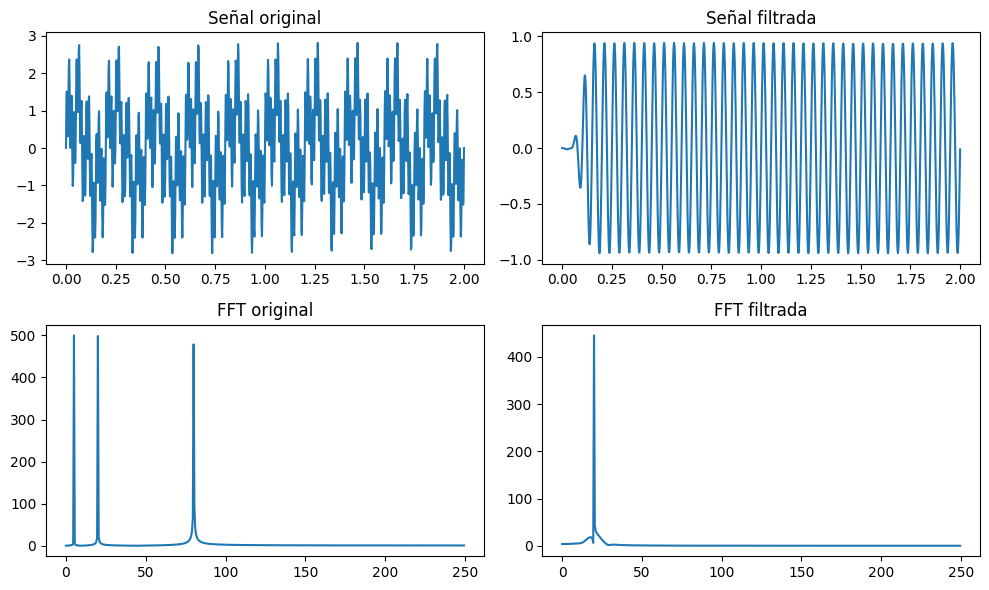

In [ ]:
#ej1
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, lfilter
from scipy.fft import fft, fftfreq

fs = 500
t = np.linspace(0, 2, 2*fs)

s1 = np.sin(2*np.pi*5*t)
s2 = np.sin(2*np.pi*20*t)
s3 = np.sin(2*np.pi*80*t)

signal = s1 + s2 + s3

fir = firwin(
    101,
    [15,30],
    pass_zero=False,
    fs=fs
)

filtered = lfilter(fir, 1.0, signal)

fft_original = np.abs(fft(signal))
fft_filtered = np.abs(fft(filtered))

freqs = fftfreq(len(signal), 1/fs)

plt.figure(figsize=(10,6))

plt.subplot(2,2,1)
plt.plot(t, signal)
plt.title("Señal original")

plt.subplot(2,2,2)
plt.plot(t, filtered)
plt.title("Señal filtrada")

plt.subplot(2,2,3)
plt.plot(freqs[:len(freqs)//2],
         fft_original[:len(freqs)//2])
plt.title("FFT original")

plt.subplot(2,2,4)
plt.plot(freqs[:len(freqs)//2],
         fft_filtered[:len(freqs)//2])
plt.title("FFT filtrada")

plt.tight_layout()
plt.show()

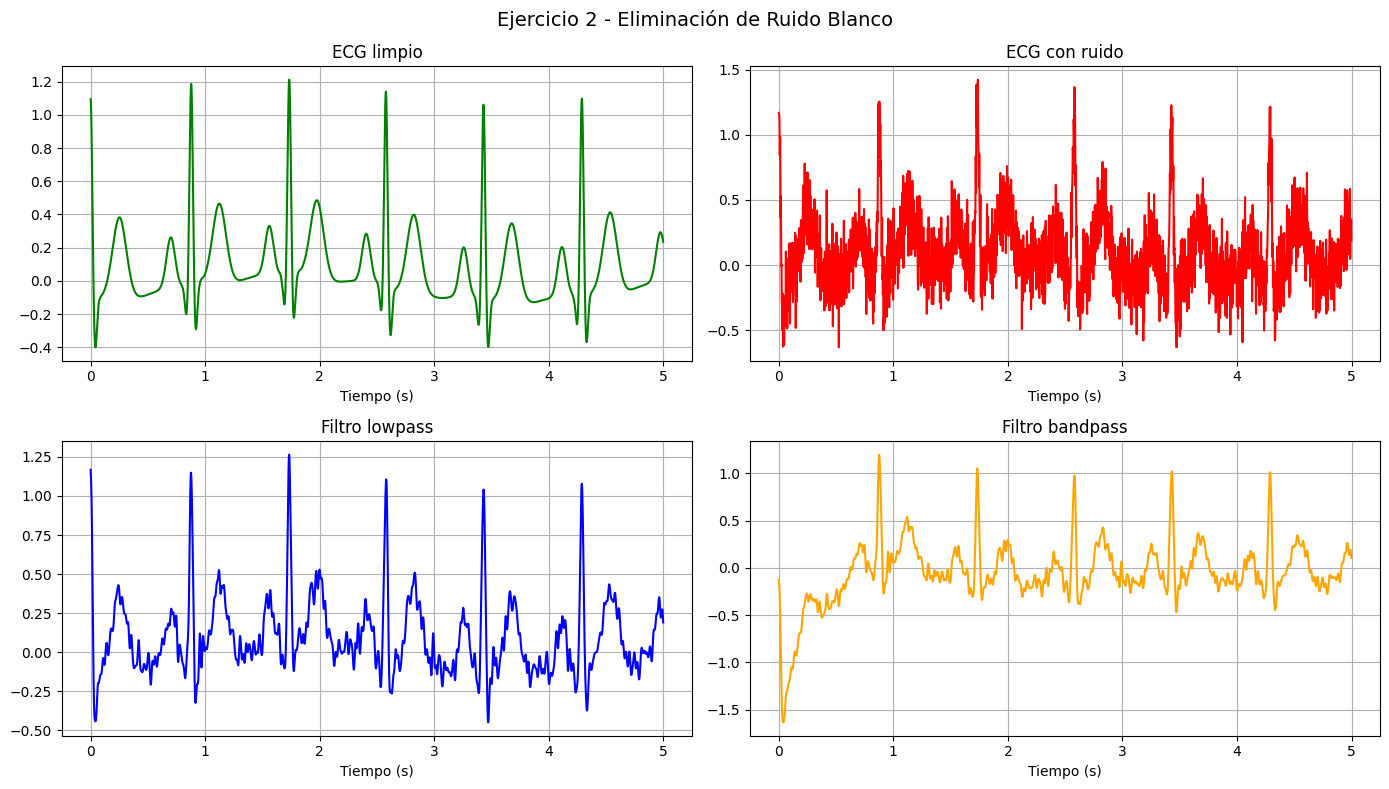

In [ ]:
#ej2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import neurokit2 as nk

fs = 500

ecg_clean = nk.ecg_simulate(
    duration=5,
    sampling_rate=fs,
    heart_rate=70,
    noise=0.01
)

t = np.linspace(0, 5, len(ecg_clean), endpoint=False)

np.random.seed(42)
white_noise = np.random.normal(0, 0.15, len(ecg_clean))

hf_noise = 0.1 * np.sin(2 * np.pi * 120 * t)

noisy = ecg_clean + white_noise + hf_noise

b_lp, a_lp = butter(4, 40, btype='low', fs=fs)

ecg_lowpass = filtfilt(b_lp, a_lp, noisy)

b_bp, a_bp = butter(4, [0.5, 40], btype='bandpass', fs=fs)

ecg_bandpass = filtfilt(b_bp, a_bp, noisy)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

fig.suptitle(
    "Ejercicio 2 - Eliminación de Ruido Blanco",
    fontsize=14
)

axes[0, 0].plot(t, ecg_clean, color='green')
axes[0, 0].set_title("ECG limpio")

axes[0, 1].plot(t, noisy, color='red')
axes[0, 1].set_title("ECG con ruido")

axes[1, 0].plot(t, ecg_lowpass, color='blue')
axes[1, 0].set_title("Filtro lowpass")

axes[1, 1].plot(t, ecg_bandpass, color='orange')
axes[1, 1].set_title("Filtro bandpass")

for ax in axes.flat:
    ax.set_xlabel("Tiempo (s)")
    ax.grid(True)

plt.tight_layout()
plt.show()

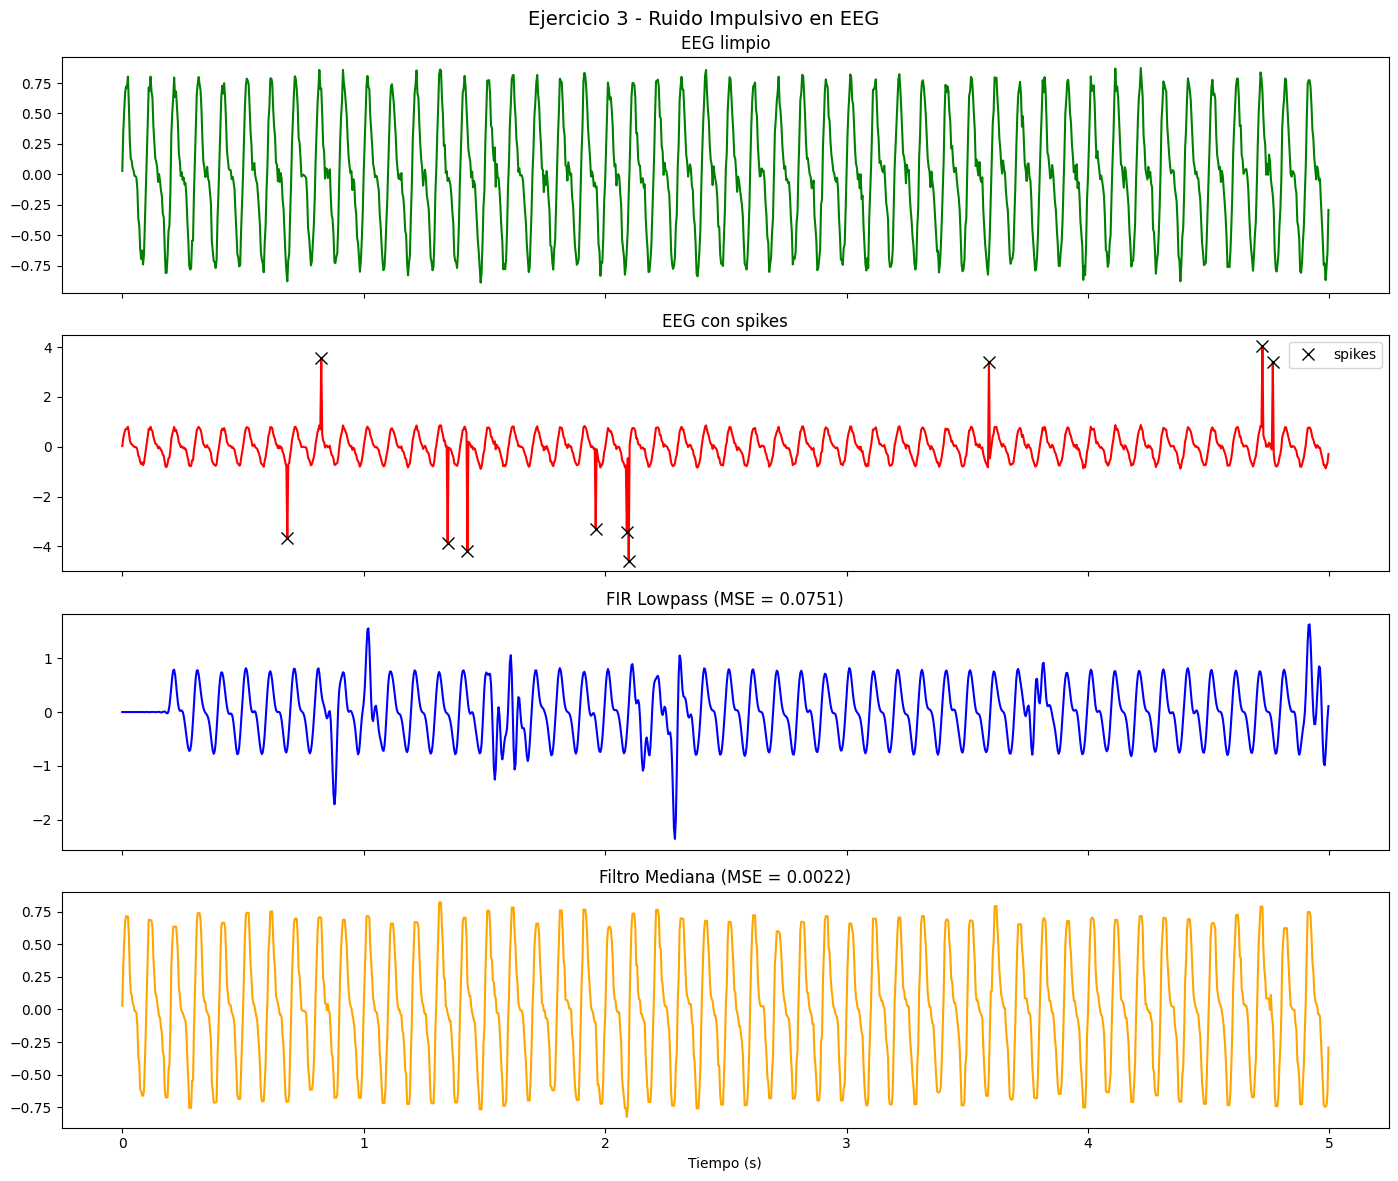

MSE FIR Lowpass: 0.075083
MSE Filtro Mediana: 0.002168

Mejor filtro: Mediana
El filtro de mediana elimina mejor los spikes
y mantiene mejor la forma de la señal EEG.


In [ ]:
#ej3
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, lfilter, medfilt

fs = 256
duration = 5

t = np.linspace(0, duration, int(fs * duration), endpoint=False)

eeg = (
    0.6 * np.sin(2 * np.pi * 10 * t) +
    0.3 * np.sin(2 * np.pi * 20 * t) +
    0.05 * np.random.randn(len(t))
)

np.random.seed(7)

spike_idx = np.random.randint(0, len(eeg), 10)

noisy_eeg = eeg.copy()

for idx in spike_idx:
    noisy_eeg[idx] += (
        np.random.choice([-1, 1]) *
        np.random.uniform(2, 5)
    )

fir = firwin(101, 40, fs=fs)

eeg_fir = lfilter(fir, 1.0, noisy_eeg)

eeg_median = medfilt(noisy_eeg, kernel_size=5)

mse_fir = np.mean((eeg_fir - eeg) ** 2)

mse_median = np.mean((eeg_median - eeg) ** 2)


fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

fig.suptitle(
    "Ejercicio 3 - Ruido Impulsivo en EEG",
    fontsize=14
)

axes[0].plot(t, eeg, color='green')
axes[0].set_title("EEG limpio")

axes[1].plot(t, noisy_eeg, color='red')

axes[1].plot(
    t[spike_idx],
    noisy_eeg[spike_idx],
    'kx',
    ms=8,
    label='spikes'
)

axes[1].set_title("EEG con spikes")
axes[1].legend()

axes[2].plot(t, eeg_fir, color='blue')

axes[2].set_title(
    f"FIR Lowpass (MSE = {mse_fir:.4f})"
)

axes[3].plot(t, eeg_median, color='orange')

axes[3].set_title(
    f"Filtro Mediana (MSE = {mse_median:.4f})"
)

axes[3].set_xlabel("Tiempo (s)")

plt.tight_layout()
plt.show()


print(f"MSE FIR Lowpass: {mse_fir:.6f}")

print(f"MSE Filtro Mediana: {mse_median:.6f}")

if mse_median < mse_fir:
    winner = "Mediana"
else:
    winner = "FIR Lowpass"

print(f"\nMejor filtro: {winner}")

print("El filtro de mediana elimina mejor los spikes")
print("y mantiene mejor la forma de la señal EEG.")